# Statistical Analysis of Household Waste Management Practices and Satisfaction in Sri Lanka

### CCS/CIS 2043 - Statistical Distribution and Inferences - 2026

**Project Type:** Statistical Analysis and Predictive Modelling

**Dataset:** Household Waste Management Survey

**Sample Size:** 185 respondents

---

## Project Overview

This project analyzes household waste management practices using descriptive statistics, inferential statistical methods, and regression models.

The analysis focuses on:

- Household and demographic characteristics
- Waste generation patterns
- Waste separation and recycling practices
- Waste collection services
- Monthly waste-management expenditure
- Distance to collection points
- Household satisfaction with waste management services

The project consists of three major analytical components:

1. Descriptive Analysis
2. Inferential Analysis
3. Regression Analysis

Three regression models are developed and compared to identify the model that provides the best predictive performance for household waste-management satisfaction.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, spearmanr

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

The cleaned household waste-management survey dataset is loaded into Google Colab.

The dataset contains 185 survey responses and 49 variables.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Waste_Survey.xlsx to Waste_Survey.xlsx


In [ ]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, engine="openpyxl")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 185
Columns: 49


In [ ]:
# Display first five rows

df.head()

,Q1. Age,Q2. Province,Q3. District,Q4. Local Authority,Q5. Area Type,Q6. Place Type,Q7. No. of People,Q8. Land Size,Q9. Waste Storage Method,Q10. Bag Size,...,Q16. How Recycle?,Q17. Income from Recyclables?,Q18. Monthly Income (Rs.),Q19. Distance to Collection Point,Q20. Collection Frequency,Q21. Disposal Method,Q22. Monthly Spend (Rs.),Q23. Biggest Problem,Q24. Use Mobile App?,Q25. Satisfaction
0,70 years and above,Western,Colombo (කොළඹ),Maharagama Urban Council,Urban (නාගරික),Household,5 - 6 persons,10–19 perches (250–499 m²),Waste Bags,Medium Bag,...,Hand over to recycling centers,Yes,"Rs. 5,000 and above",More than 2 km,Weekly,Municipal collection service (මහ නගර / ප්‍රාදේ...,No expenditure,Other: __________,Yes,Very Satisfied
1,50 - 59 years,Western,Gampaha (ගම්පහ),Gampaha Municipal Council,Semi-urban (අර්ධ නාගරික),Household,5 - 6 persons,10–19 perches (250–499 m²),Both Bags and Bins,Large Bag,...,Sell to collectors,Yes,Less than Rs. 500,More than 2 km,Other: __________,Municipal collection service (මහ නගර / ප්‍රාදේ...,Less than Rs. 500,Lack of recycling facilities,Yes,Very Dissatisfied
2,20 - 29 years,Western,Colombo (කොළඹ),Colombo Municipal Council,Semi-urban (අර්ධ නාගරික),Household,3 - 4 persons,Less than 10 perches (<250 m²),Waste Bins,NaN,...,Reuse at home,No,NaN,More than 2 km,Weekly,Municipal collection service (මහ නගර / ප්‍රාදේ...,No expenditure,Limited space for waste storage,Yes,Satisfied
3,20 - 29 years,Southern,Galle (ගාල්ල),Bentota Pradeshiya Sabha,Semi-urban (අර්ධ නාගරික),Household,5 - 6 persons,20–39 perches (500–999 m²),Other (Specify),Medium Bag,...,Reuse at home,Yes,Less than Rs. 500,No collection point available,Other: __________,"Composting (කොම්පෝස්ට් කිරීම), Burying (වළ දැම...","Rs. 1,000–2,999","Irregular waste collection, Lack of awareness,...",Yes,Neutral
4,20 - 29 years,Western,Kalutara (කළුතර),Madurawala Pradeshiya Sabha,Rural (ග්‍රාමීය),Household,More than 8 persons,20–39 perches (500–999 m²),Both Bags and Bins,Extra Large Bag,...,NaN,No,NaN,1–2 km,Other: __________,Burning in an open area (විවෘතව ගිනි තැබීම),No expenditure,Limited space for waste storage,Yes,Neutral


In [ ]:
# Display last five rows

df.tail()

,Q1. Age,Q2. Province,Q3. District,Q4. Local Authority,Q5. Area Type,Q6. Place Type,Q7. No. of People,Q8. Land Size,Q9. Waste Storage Method,Q10. Bag Size,...,Q16. How Recycle?,Q17. Income from Recyclables?,Q18. Monthly Income (Rs.),Q19. Distance to Collection Point,Q20. Collection Frequency,Q21. Disposal Method,Q22. Monthly Spend (Rs.),Q23. Biggest Problem,Q24. Use Mobile App?,Q25. Satisfaction
180,20 - 29 years,Western,Kalutara (කළුතර),Beruwala Urban Council,Semi-urban (අර්ධ නාගරික),Household,5 - 6 persons,10–19 perches (250–499 m²),Both Bags and Bins,Large Bag,...,NaN,No,NaN,More than 2 km,Twice a week,Municipal collection service (මහ නගර / ප්‍රාදේ...,Less than Rs. 500,Irregular waste collection,Yes,Neutral
181,20 - 29 years,North Western,Kurunegala (කුරුණෑගල),Udubaddawa Pradeshiya Sabha,Rural (ග්‍රාමීය),Household,3 - 4 persons,80 perches and above (>2000 m²),Waste Bins,NaN,...,Sell to collectors,Yes,"Rs. 1,000–2,999",1–2 km,Weekly,Composting (කොම්පෝස්ට් කිරීම),No expenditure,Lack of recycling facilities,No,Neutral
182,20 - 29 years,Western,Gampaha (ගම්පහ),Gampaha Pradeshiya Sabha,Urban (නාගරික),Household,3 - 4 persons,20–39 perches (500–999 m²),Waste Bags,Medium Bag,...,Hand over to recycling centers,Yes,Rs. 500–999,100–499 m,Weekly,Municipal collection service (මහ නගර / ප්‍රාදේ...,No expenditure,Irregular waste collection,Yes,Satisfied
183,20 - 29 years,Southern,Galle (ගාල්ල),Bope Poddala Pradeshiya Sabha,Urban (නාගරික),Household,3 - 4 persons,20–39 perches (500–999 m²),Both Bags and Bins,Large Bag,...,NaN,No,NaN,Less than 100 m,Weekly,Burying (වළ දැමීම),No expenditure,"Irregular waste collection, Limited space for ...",Yes,Neutral
184,40 - 49 years,Western,Kalutara (කළුතර),Panadura Urban Council,Urban (නාගරික),Household,5 - 6 persons,10–19 perches (250–499 m²),Both Bags and Bins,Large Bag,...,NaN,No,NaN,1–2 km,Weekly,Private collection service (පෞද්ගලික එකතු කිරී...,Rs. 500–999,Bad smell/pests,Yes,Dissatisfied


## 2. Initial Data Inspection

Before performing statistical analysis, the dataset is inspected to understand:

- Number of observations
- Number of variables
- Variable data types
- Missing values
- Duplicate records

In [ ]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 49 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Q1. Age                            185 non-null    object
 1   Q2. Province                       185 non-null    object
 2   Q3. District                       185 non-null    object
 3   Q4. Local Authority                185 non-null    object
 4   Q5. Area Type                      185 non-null    object
 5   Q6. Place Type                     185 non-null    object
 6   Q7. No. of People                  185 non-null    object
 7   Q8. Land Size                      185 non-null    object
 8   Q9. Waste Storage Method           185 non-null    object
 9   Q10. Bag Size                      110 non-null    object
 10  Q11. Bin Size                      156 non-null    object
 11  Q12a. Food Waste (bags)            107 non-null    object
 12  Q12b. Ga

In [ ]:
# Dataset dimensions

print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 185
Number of variables: 49


In [ ]:
# Display column names

for i, column in enumerate(df.columns, start=1):
    print(i, ".", column)

1 . Q1. Age
2 . Q2. Province
3 . Q3. District
4 . Q4. Local Authority
5 . Q5. Area Type
6 . Q6. Place Type
7 . Q7. No. of People
8 . Q8. Land Size
9 . Q9. Waste Storage Method
10 . Q10. Bag Size
11 . Q11. Bin Size
12 . Q12a. Food Waste (bags)
13 . Q12b. Garden Waste (bags)
14 . Q12c. Plastic (bags)
15 . Q12d. Paper (bags)
16 . Q12e. Glass (bags)
17 . Q12f. Metal (bags)
18 . Q12g. E-Waste (bags)
19 . Q12h. Textile (bags)
20 . Q12i. Rubber (bags)
21 . Q12j. Coconut (bags)
22 . Q12k. Packaging (bags)
23 . Q12l. Medical (bags)
24 . Q12m. Other (bags)
25 . Q13a. Food Waste (bins)
26 . Q13b. Garden Waste (bins)
27 . Q13c. Plastic (bins)
28 . Q13d. Paper (bins)
29 . Q13e. Glass (bins)
30 . Q13f. Metal (bins)
31 . Q13g. E-Waste (bins)
32 . Q13h. Textile (bins)
33 . Q13i. Rubber (bins)
34 . Q13j. Coconut (bins)
35 . Q13k. Packaging (bins)
36 . Q13l. Medical (bins)
37 . Q13m. Other (bins)
38 . Q14. Separate Recyclables?
39 . Q15. Recycle Waste?
40 . Q16. How Recycle?
41 . Q17. Income from Recycl

Check Missing Values

In [ ]:
# Count missing values in each column

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (missing_values.values / len(df)) * 100
})

missing_table = missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

missing_table.head(20)

,Column,Missing Values,Missing Percentage
23,Q12m. Other (bags),110,59.459459
36,Q13m. Other (bins),100,54.054054
41,Q18. Monthly Income (Rs.),90,48.648649
18,Q12h. Textile (bags),87,47.027027
19,Q12i. Rubber (bags),87,47.027027
16,Q12f. Metal (bags),87,47.027027
15,Q12e. Glass (bags),86,46.486486
22,Q12l. Medical (bags),86,46.486486
20,Q12j. Coconut (bags),86,46.486486
17,Q12g. E-Waste (bags),86,46.486486


Check Duplicates

In [ ]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Remove duplicate rows if any

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (185, 49)


## 3. Data Cleaning and Preparation

The dataset contains categorical responses and some missing values.

For the statistical and machine-learning analysis:

- Duplicate records are removed.
- Numeric waste variables are converted into numeric format.
- Missing numeric values are handled using median imputation.
- Missing categorical values are handled using the most frequent category.
- Categorical variables are converted into numerical form when required.

In [ ]:
# Identify waste quantity columns

bag_columns = [col for col in df.columns if "(bags)" in col]
bin_columns = [col for col in df.columns if "(bins)" in col]

print("Number of bag-related variables:", len(bag_columns))
print("Number of bin-related variables:", len(bin_columns))

Number of bag-related variables: 13
Number of bin-related variables: 13


Convert Waste Columns to Numeric

In [ ]:
# Convert waste quantity columns into numeric values

for col in bag_columns + bin_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Waste quantity columns converted to numeric format.")

Waste quantity columns converted to numeric format.


## 4. Feature Engineering

Several new variables are created from the original survey variables.

### Engineered Features

**Total Bag Waste**

The total number of waste bags reported across all waste categories.

**Total Bin Waste**

The total number of waste bins reported across all waste categories.

**Total Waste Quantity**

A combined measure of reported waste quantity.

**Satisfaction Score**

The categorical satisfaction response is converted into an ordinal numerical score:

- Very Dissatisfied = 1
- Dissatisfied = 2
- Neutral = 3
- Satisfied = 4
- Very Satisfied = 5

In [ ]:
# Calculate total waste quantities

df["Total Bag Waste"] = df[bag_columns].sum(axis=1, skipna=True)

df["Total Bin Waste"] = df[bin_columns].sum(axis=1, skipna=True)

df["Total Waste Quantity"] = (
    df["Total Bag Waste"] +
    df["Total Bin Waste"]
)

print(df[
    ["Total Bag Waste",
     "Total Bin Waste",
     "Total Waste Quantity"]
].head())

   Total Bag Waste  Total Bin Waste  Total Waste Quantity
0              2.0              0.0                   2.0
1              5.0              3.0                   8.0
2              0.0              1.0                   1.0
3              4.0              4.0                   8.0
4              4.0              1.0                   5.0


Convert Satisfaction to Numerical Score

In [ ]:
# Convert satisfaction levels into numerical scores

satisfaction_mapping = {
    "Very Dissatisfied": 1,
    "Dissatisfied": 2,
    "Neutral": 3,
    "Satisfied": 4,
    "Very Satisfied": 5
}

df["Satisfaction Score"] = df["Q25. Satisfaction"].map(
    satisfaction_mapping
)

print(df["Satisfaction Score"].value_counts().sort_index())

Satisfaction Score
1    18
2     9
3    97
4    53
5     8
Name: count, dtype: int64


# 5. Descriptive Analysis

Descriptive analysis is used to summarize the main characteristics of the survey data.

The analysis includes:

- Frequencies
- Percentages
- Measures of central tendency
- Measures of dispersion
- Distribution of satisfaction levels
- Waste-generation patterns

In [ ]:
# Descriptive statistics for numerical variables

numeric_summary = df[
    [
        "Total Bag Waste",
        "Total Bin Waste",
        "Total Waste Quantity",
        "Satisfaction Score"
    ]
].describe()

numeric_summary

,Total Bag Waste,Total Bin Waste,Total Waste Quantity,Satisfaction Score
count,185.000000,185.000000,185.000000,185.000000
mean,3.621622,3.394595,7.016216,3.129730
std,6.430022,6.876312,10.378424,0.940879
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,1.000000,3.000000
50%,1.000000,1.000000,3.000000,3.000000
75%,4.000000,4.000000,9.000000,4.000000
max,31.000000,71.000000,74.000000,5.000000


Satisfaction Distribution

In [ ]:
# Frequency table for satisfaction

satisfaction_frequency = df["Q25. Satisfaction"].value_counts()

satisfaction_frequency

,count
Q25. Satisfaction,
Neutral,97
Satisfied,53
Very Dissatisfied,18
Dissatisfied,9
Very Satisfied,8


In [ ]:
# Percentage distribution

satisfaction_percentage = (
    df["Q25. Satisfaction"]
    .value_counts(normalize=True) * 100
).round(2)

satisfaction_percentage

,proportion
Q25. Satisfaction,
Neutral,52.43
Satisfied,28.65
Very Dissatisfied,9.73
Dissatisfied,4.86
Very Satisfied,4.32


Satisfaction Bar Chart

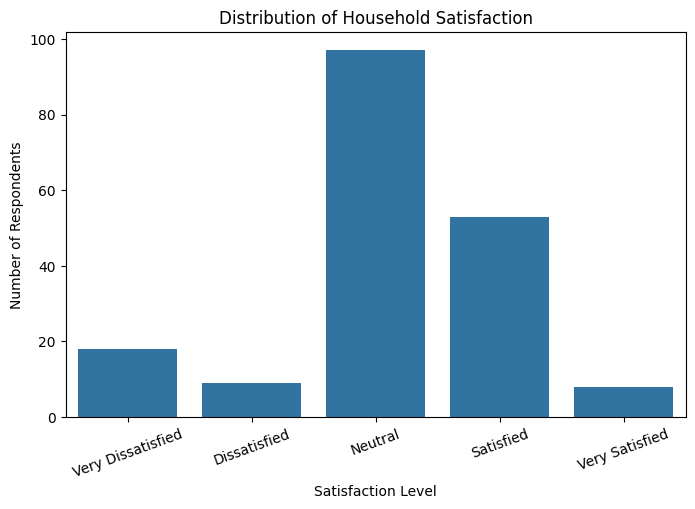

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Q25. Satisfaction",
    order=[
        "Very Dissatisfied",
        "Dissatisfied",
        "Neutral",
        "Satisfied",
        "Very Satisfied"
    ]
)

plt.title("Distribution of Household Satisfaction")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)
plt.show()

Province Distribution

In [ ]:
province_counts = df["Q2. Province"].value_counts()

province_counts

,count
Q2. Province,
Western,130
Southern,42
North Western,13


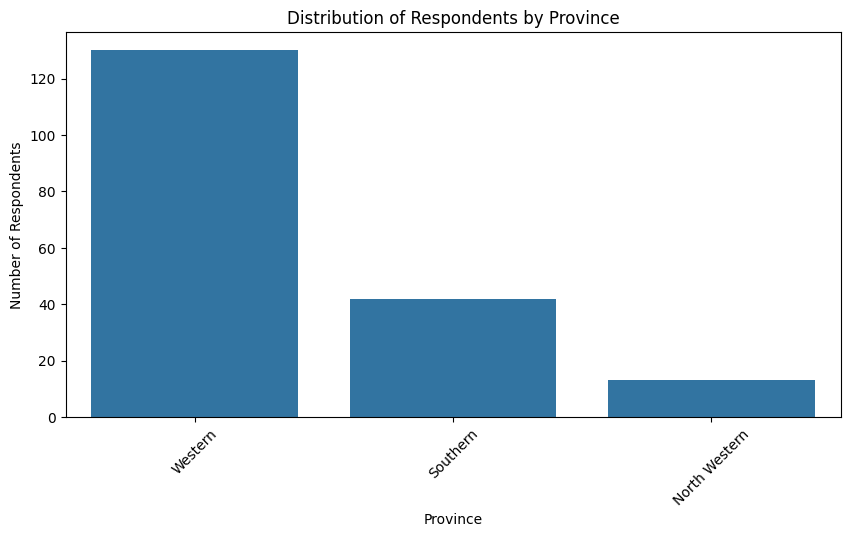

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Q2. Province",
    order=df["Q2. Province"].value_counts().index
)

plt.title("Distribution of Respondents by Province")
plt.xlabel("Province")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.show()

Waste Quantity Distribution

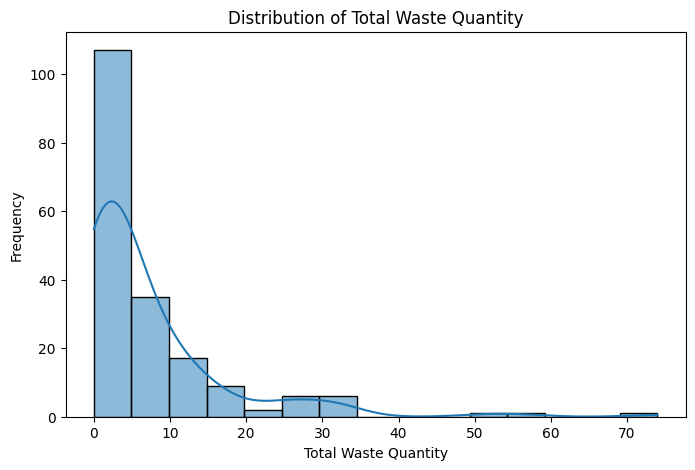

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total Waste Quantity"],
    bins=15,
    kde=True
)

plt.title("Distribution of Total Waste Quantity")
plt.xlabel("Total Waste Quantity")
plt.ylabel("Frequency")
plt.show()

Recycling Analysis

In [ ]:
# Recycling responses

recycling_counts = df["Q15. Recycle Waste?"].value_counts()

print(recycling_counts)

Q15. Recycle Waste?
Yes    125
No      60
Name: count, dtype: int64


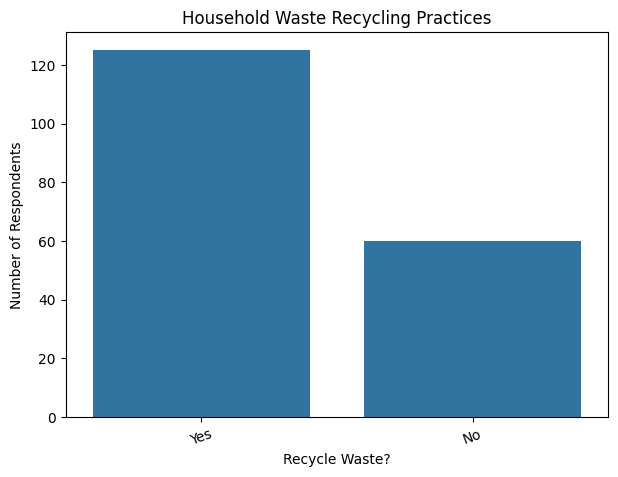

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Q15. Recycle Waste?"
)

plt.title("Household Waste Recycling Practices")
plt.xlabel("Recycle Waste?")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)
plt.show()

# 6. Inferential Analysis

Inferential statistics are used to determine whether patterns observed in the sample provide evidence of relationships or differences in the wider population.

The following statistical tests are performed:

1. Chi-Square Test of Independence
2. Kruskal-Wallis Test
3. Spearman Rank Correlation

A significance level of α = 0.05 is used.

### Decision Rule

- If p-value < 0.05 → reject the null hypothesis.
- If p-value ≥ 0.05 → fail to reject the null hypothesis.

## 6.1 Chi-Square Test of Independence

### Research Question

Is there a statistically significant association between province and household satisfaction with waste-management services?

### Null Hypothesis (H₀)

There is no significant association between province and satisfaction.

### Alternative Hypothesis (H₁)

There is a significant association between province and satisfaction.

In [ ]:
# Create contingency table

contingency_table = pd.crosstab(
    df["Q2. Province"],
    df["Q25. Satisfaction"]
)

contingency_table

Q25. Satisfaction,Dissatisfied,Neutral,Satisfied,Very Dissatisfied,Very Satisfied
Q2. Province,,,,,
North Western,1,6,3,3,0
Southern,1,20,13,6,2
Western,7,71,37,9,6


In [ ]:
# Perform Chi-Square test

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", degrees_of_freedom)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject H0")
    print("Conclusion: There is a statistically significant association between province and satisfaction.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is insufficient evidence of a significant association between province and satisfaction.")

Chi-Square Statistic: 6.375200046518857
Degrees of Freedom: 8
p-value: 0.6052812065861464
Decision: Fail to reject H0
Conclusion: There is insufficient evidence of a significant association between province and satisfaction.


## 6.2 Kruskal-Wallis Test

The Kruskal-Wallis test is used to determine whether satisfaction scores differ significantly across provinces.

### Null Hypothesis (H₀)

The distribution of satisfaction scores is the same across the provinces.

### Alternative Hypothesis (H₁)

At least one province has a different distribution of satisfaction scores.

The significance level is α = 0.05.

In [ ]:
# Prepare satisfaction scores by province

province_groups = []

for province in df["Q2. Province"].dropna().unique():
    group = df.loc[
        df["Q2. Province"] == province,
        "Satisfaction Score"
    ].dropna()

    if len(group) > 0:
        province_groups.append(group)

# Perform Kruskal-Wallis test

if len(province_groups) >= 2:
    statistic, p_value = kruskal(*province_groups)

    print("Kruskal-Wallis Statistic:", statistic)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("Decision: Reject H0")
        print("Conclusion: There is a statistically significant difference in satisfaction across provinces.")
    else:
        print("Decision: Fail to reject H0")
        print("Conclusion: There is insufficient evidence of a significant difference in satisfaction across provinces.")
else:
    print("Not enough groups for the Kruskal-Wallis test.")

Kruskal-Wallis Statistic: 2.1653451224016975
p-value: 0.33868914753409474
Decision: Fail to reject H0
Conclusion: There is insufficient evidence of a significant difference in satisfaction across provinces.


## 6.3 Spearman Rank Correlation

Spearman correlation is used to investigate whether total waste quantity is associated with household satisfaction.

### Null Hypothesis (H₀)

There is no monotonic relationship between total waste quantity and satisfaction.

### Alternative Hypothesis (H₁)

There is a monotonic relationship between total waste quantity and satisfaction.

The significance level is α = 0.05.

In [ ]:
# Spearman correlation

correlation, p_value = spearmanr(
    df["Total Waste Quantity"],
    df["Satisfaction Score"],
    nan_policy="omit"
)

print("Spearman Correlation:", correlation)
print("p-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: There is a statistically significant monotonic relationship.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is insufficient evidence of a statistically significant monotonic relationship.")

Spearman Correlation: -0.12984545449905602
p-value: 0.07813960148980108
Decision: Fail to reject H0
Conclusion: There is insufficient evidence of a statistically significant monotonic relationship.


# 7. Regression Analysis

Regression analysis is used to model household satisfaction based on selected demographic, waste-management, recycling, collection, and expenditure variables.

The dependent variable is:

**Satisfaction Score**

where:

- 1 = Very Dissatisfied
- 2 = Dissatisfied
- 3 = Neutral
- 4 = Satisfied
- 5 = Very Satisfied

Three regression models are developed:

1. Multiple Linear Regression
2. Random Forest Regression
3. Gradient Boosting Regression

The models are evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Select Features

In [ ]:
# Select independent variables

features = [
    "Q1. Age",
    "Q2. Province",
    "Q3. District",
    "Q5. Area Type",
    "Q7. No. of People",
    "Q8. Land Size",
    "Q14. Separate Recyclables?",
    "Q15. Recycle Waste?",
    "Q17. Income from Recyclables?",
    "Q19. Distance to Collection Point",
    "Q20. Collection Frequency",
    "Q21. Disposal Method",
    "Q22. Monthly Spend (Rs.)",
    "Q23. Biggest Problem",
    "Q24. Use Mobile App?",
    "Total Bag Waste",
    "Total Bin Waste",
    "Total Waste Quantity"
]

target = "Satisfaction Score"

X = df[features].copy()
y = df[target].copy()

print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])

Number of features: 18
Number of observations: 185


Identify Numeric and Categorical Variables

In [ ]:
numeric_features = [
    "Total Bag Waste",
    "Total Bin Waste",
    "Total Waste Quantity"
]

categorical_features = [
    col for col in features
    if col not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Total Bag Waste', 'Total Bin Waste', 'Total Waste Quantity']

Categorical features:
['Q1. Age', 'Q2. Province', 'Q3. District', 'Q5. Area Type', 'Q7. No. of People', 'Q8. Land Size', 'Q14. Separate Recyclables?', 'Q15. Recycle Waste?', 'Q17. Income from Recyclables?', 'Q19. Distance to Collection Point', 'Q20. Collection Frequency', 'Q21. Disposal Method', 'Q22. Monthly Spend (Rs.)', 'Q23. Biggest Problem', 'Q24. Use Mobile App?']


## 7.1 Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to develop the models, while the testing data is used to evaluate their performance on unseen observations.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 148
Testing observations: 37


Preprocessing Pipeline

In [ ]:
# Preprocessing for numeric variables

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Preprocessing for categorical variables

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 7.2 Model 1 - Multiple Linear Regression

Multiple Linear Regression is used as the baseline regression model.

It estimates the relationship between the selected independent variables and household satisfaction.

In [ ]:
# Create Linear Regression pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train model

linear_model.fit(X_train, y_train)

# Predict

linear_predictions = linear_model.predict(X_test)

print("Multiple Linear Regression completed.")

Multiple Linear Regression completed.


Evaluate Linear Regression

In [ ]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 0.8766
RMSE: 1.04
R²  : -0.599


## 7.3 Model 2 - Random Forest Regression

Random Forest Regression is an ensemble machine-learning method that combines multiple decision trees.

It can model nonlinear relationships between waste-management characteristics and satisfaction.

In [ ]:
# Create Random Forest pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                max_depth=None
            )
        )
    ]
)

# Train

random_forest_model.fit(
    X_train,
    y_train
)

# Predict

rf_predictions = random_forest_model.predict(X_test)

print("Random Forest Regression completed.")

Random Forest Regression completed.


Evaluate Random Forest

In [ ]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest Results
---------------------
MAE : 0.6724
RMSE: 0.7882
R²  : 0.0816


## 7.4 Model 3 - Gradient Boosting Regression

Gradient Boosting Regression builds multiple weak prediction models sequentially.

Each new model attempts to reduce the prediction errors made by previous models.

In [ ]:
# Create Gradient Boosting pipeline

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

# Train

gradient_boosting_model.fit(
    X_train,
    y_train
)

# Predict

gb_predictions = gradient_boosting_model.predict(X_test)

print("Gradient Boosting Regression completed.")

Gradient Boosting Regression completed.


Evaluate Gradient Boosting

In [ ]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae, 4))
print("RMSE:", round(gb_rmse, 4))
print("R²  :", round(gb_r2, 4))

Gradient Boosting Results
-------------------------
MAE : 0.6563
RMSE: 0.7617
R²  : 0.1423


# 8. Regression Model Comparison

The three developed regression models are compared using MAE, RMSE, and R².

### Interpretation of Metrics

**MAE - Mean Absolute Error**

Measures the average absolute difference between the actual and predicted values. Lower values indicate smaller prediction errors.

**RMSE - Root Mean Squared Error**

Measures the square root of the average squared prediction error. Lower values indicate better predictive performance.

**R² - Coefficient of Determination**

Measures the proportion of variation in the target variable explained by the model. Higher values generally indicate better explanatory performance.

In [ ]:
# Create model comparison table

comparison = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Random Forest Regression",
        "Gradient Boosting Regression"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,0.876559,1.040000,-0.599039
1,Random Forest Regression,0.672432,0.788154,0.081637
2,Gradient Boosting Regression,0.656338,0.761691,0.142272


Round Results

In [ ]:
comparison_rounded = comparison.copy()

comparison_rounded["MAE"] = comparison_rounded["MAE"].round(4)
comparison_rounded["RMSE"] = comparison_rounded["RMSE"].round(4)
comparison_rounded["R2"] = comparison_rounded["R2"].round(4)

comparison_rounded

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,0.8766,1.0400,-0.5990
1,Random Forest Regression,0.6724,0.7882,0.0816
2,Gradient Boosting Regression,0.6563,0.7617,0.1423


Visual Model Comparison

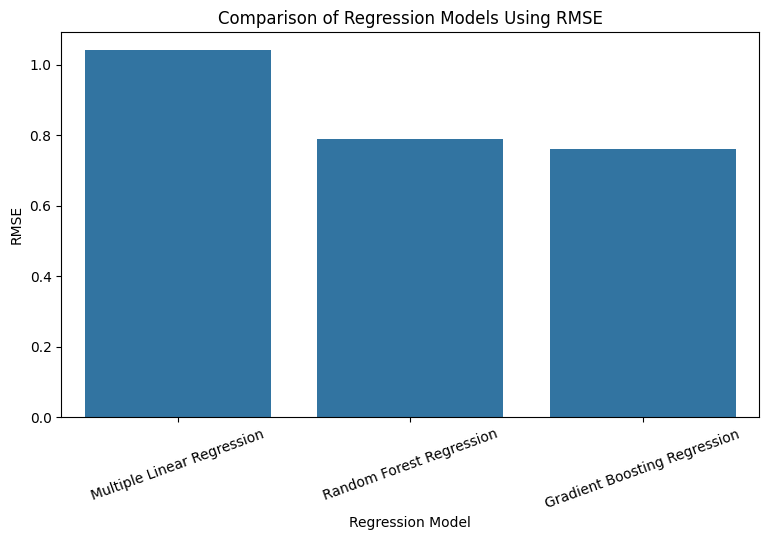

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("Comparison of Regression Models Using RMSE")
plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

## 8.1 Best-Performing Model

For this analysis, RMSE is used as the primary model-selection criterion because it measures prediction error and gives greater weight to larger errors.

The model with the lowest RMSE is selected as the best-performing model according to this criterion.

In [ ]:
# Select model with the lowest RMSE

best_model_row = comparison.loc[
    comparison["RMSE"].idxmin()
]

best_model_name = best_model_row["Model"]
best_rmse = best_model_row["RMSE"]
best_mae = best_model_row["MAE"]
best_r2 = best_model_row["R2"]

print("Best-performing model based on RMSE:")
print(best_model_name)

print("\nPerformance:")
print("MAE :", round(best_mae, 4))
print("RMSE:", round(best_rmse, 4))
print("R²  :", round(best_r2, 4))

Best-performing model based on RMSE:
Gradient Boosting Regression

Performance:
MAE : 0.6563
RMSE: 0.7617
R²  : 0.1423


# 9. Feature Importance

Feature importance is examined to identify variables that contribute most to the predictions made by the tree-based models.

This provides additional insight into which waste-management characteristics are most useful for predicting satisfaction.

In [ ]:
# Extract transformed feature names

preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

# Extract Random Forest feature importance

rf_importances = random_forest_model.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
58,cat__Q21. Disposal Method_Burning in an open a...,0.086349
43,cat__Q19. Distance to Collection Point_No coll...,0.077137
1,num__Total Bin Waste,0.064265
2,num__Total Waste Quantity,0.060390
53,cat__Q20. Collection Frequency_Once every two ...,0.036141
49,cat__Q20. Collection Frequency_No,0.030958
0,num__Total Bag Waste,0.030809
3,cat__Q1. Age_20 - 29 years,0.026006
5,cat__Q1. Age_40 - 49 years,0.021343
55,cat__Q20. Collection Frequency_Twice a week,0.019321


Feature Importance Chart

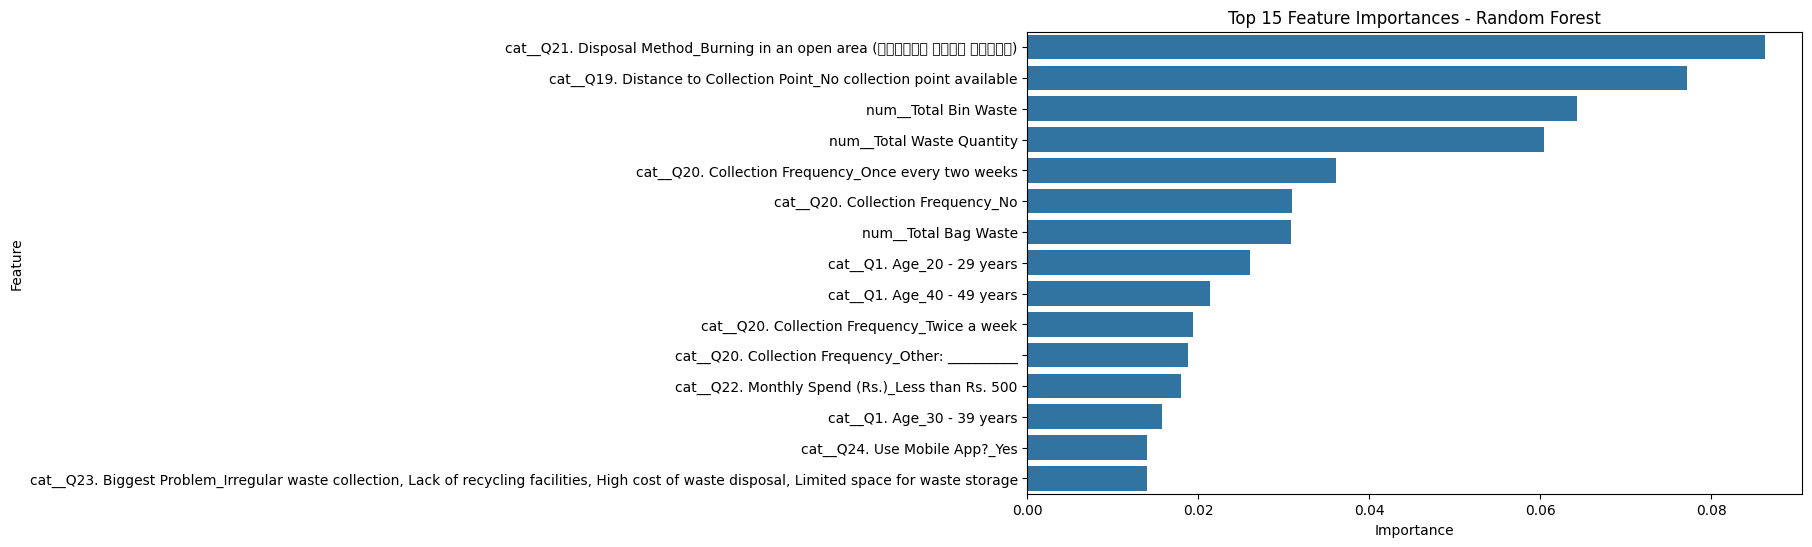

In [ ]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Actual vs Predicted Values

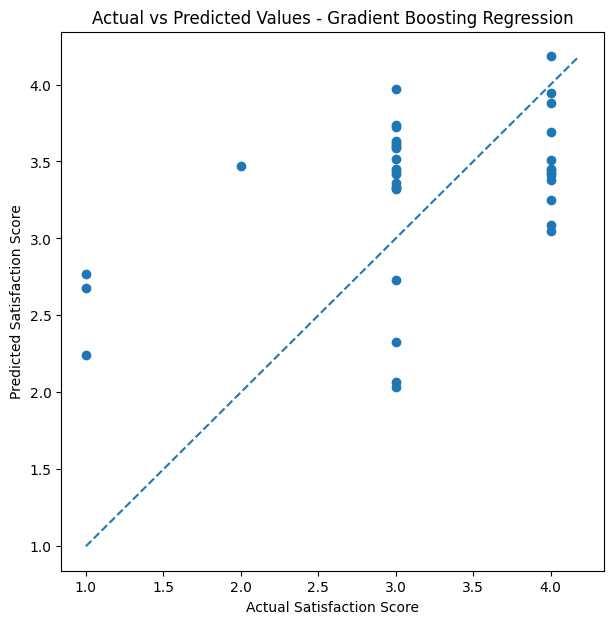

In [ ]:
# Choose predictions from the best RMSE model

predictions = {
    "Multiple Linear Regression": linear_predictions,
    "Random Forest Regression": rf_predictions,
    "Gradient Boosting Regression": gb_predictions
}

best_predictions = predictions[best_model_name]

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual Satisfaction Score")
plt.ylabel("Predicted Satisfaction Score")
plt.title(f"Actual vs Predicted Values - {best_model_name}")

# Reference line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

# 10. Final Findings

## Descriptive Findings

The descriptive analysis summarizes household characteristics, waste-generation patterns, recycling practices, collection services, expenditure, and satisfaction levels.

The distribution of satisfaction levels provides an overview of how respondents perceive the existing waste-management services.

The analysis of waste quantities provides an indication of the amount and types of waste generated by surveyed households.

## Inferential Findings

The Chi-Square test was used to investigate the association between province and satisfaction.

The Kruskal-Wallis test was used to determine whether satisfaction scores differed across provinces.

Spearman rank correlation was used to examine the relationship between total waste quantity and satisfaction.

The statistical decisions were made using a significance level of α = 0.05.

## Regression Findings

Three regression models were developed:

1. Multiple Linear Regression
2. Random Forest Regression
3. Gradient Boosting Regression

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

The model comparison was performed using the same test dataset for all three models.

The model with the lowest RMSE was selected as the best-performing model according to the predefined evaluation criterion.

Feature importance analysis was also performed to identify variables that contributed most to predictions in the Random Forest model.

## Overall Conclusion

This study demonstrates how statistical analysis and regression modelling can be used to investigate household waste-management practices and satisfaction.

The combination of descriptive statistics, inferential statistics, feature engineering, and predictive modelling provides a comprehensive analysis of the survey dataset.

The findings can provide useful statistical evidence regarding household waste-management behaviour, recycling practices, collection services, and satisfaction.

Final Model Summary Automatically

In [ ]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print("\nBest-performing model based on lowest RMSE:")
print(best_model_name)

print("\nPerformance:")
print(f"MAE  : {best_mae:.4f}")
print(f"RMSE : {best_rmse:.4f}")
print(f"R²   : {best_r2:.4f}")

print("\nAll model results:")
display(comparison_rounded)

print("\nTop 10 Random Forest Features:")
display(feature_importance.head(10))

FINAL MODEL SUMMARY

Best-performing model based on lowest RMSE:
Gradient Boosting Regression

Performance:
MAE  : 0.6563
RMSE : 0.7617
R²   : 0.1423

All model results:


,Model,MAE,RMSE,R2
0,Multiple Linear Regression,0.8766,1.0400,-0.5990
1,Random Forest Regression,0.6724,0.7882,0.0816
2,Gradient Boosting Regression,0.6563,0.7617,0.1423



Top 10 Random Forest Features:


,Feature,Importance
58,cat__Q21. Disposal Method_Burning in an open a...,0.086349
43,cat__Q19. Distance to Collection Point_No coll...,0.077137
1,num__Total Bin Waste,0.064265
2,num__Total Waste Quantity,0.060390
53,cat__Q20. Collection Frequency_Once every two ...,0.036141
49,cat__Q20. Collection Frequency_No,0.030958
0,num__Total Bag Waste,0.030809
3,cat__Q1. Age_20 - 29 years,0.026006
5,cat__Q1. Age_40 - 49 years,0.021343
55,cat__Q20. Collection Frequency_Twice a week,0.019321


# 11. Conclusion

The project successfully completed the statistical analysis of the household waste-management survey.

The workflow included:

- Data loading
- Data inspection
- Data cleaning
- Feature engineering
- Descriptive analysis
- Inferential statistical analysis
- Regression modelling
- Model evaluation
- Model comparison
- Feature importance analysis
- Final interpretation

Three regression models were developed and evaluated using MAE, RMSE, and R².

The final model was selected based on the lowest RMSE on the test dataset. The model comparison provides an objective basis for identifying the model that produced the smallest prediction error among the developed models.

The statistical analysis provides an evidence-based overview of household waste-management practices and satisfaction within the surveyed population.

---

## Key Statistical Considerations

The conclusions of this study apply to the surveyed sample and should be interpreted in the context of the data collected.

Statistical significance was evaluated using α = 0.05.

Predictive model performance was evaluated using a separate test dataset that was not used during model training.